# EDA DADA-2000: Anticipación por ventanas pre-TOA


```text
training_full.txt → make_balanced_training_txt.py → training_balanced.txt → make_train_val_split.py → training_train.txt / training_val.txt → dataset.py → X3D-S + GRU
```

La tarea validada aquí es clasificación binaria de ventanas temporales previas al accidente:

- `label=0`: riesgo lejano, ventana lejana al TOA.
- `label=1`: riesgo cercano, ventana cercana al TOA.


In [4]:
from pathlib import Path
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# =============================
# CONFIGURACIÓN
# =============================
TRAIN_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_train.txt")
VAL_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_val.txt")

# Opcionales. Si los tienes en otra carpeta, cambia estas rutas.
BALANCED_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_balanced.txt")
FULL_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_full.txt")

# Opcional para visualizar frames.
# Debe contener rutas tipo RGB_ROOT / "49/022" / "0001.png".
RGB_ROOT = None  # ejemplo: Path("/data-fast/data-server/vlopezmo/DADA2000/frames")

# Parámetros de generación de ventanas.
WINDOW_LEN_EXPECTED = 64
STRIDE_EXPECTED = 16
POSITIVE_HORIZON = 30
GRAY_ZONE = 30
NEGATIVE_MIN_DISTANCE = POSITIVE_HORIZON + GRAY_ZONE + 1  # 61
NEGATIVE_MAX_DISTANCE = 120

# Parámetros del modelo X3D-S + GRU.
NUM_FRAMES_MODEL = 16
X3D_SUBCLIP_LEN = 13
X3D_SUBCLIP_STRIDE = 1
FPS_ASSUMED = 30

print("TRAIN_TXT:", TRAIN_TXT, TRAIN_TXT.exists())
print("VAL_TXT:  ", VAL_TXT, VAL_TXT.exists())
print("BALANCED: ", BALANCED_TXT, BALANCED_TXT.exists())
print("FULL:     ", FULL_TXT, FULL_TXT.exists())

TRAIN_TXT: /data-fast/data-server/vlopezmo/model/training/training_train.txt True
VAL_TXT:   /data-fast/data-server/vlopezmo/model/training/training_val.txt True
BALANCED:  /data-fast/data-server/vlopezmo/model/training/training_balanced.txt True
FULL:      /data-fast/data-server/vlopezmo/model/training/training_full.txt True


## 1. Parser de los `.txt`

Formato esperado:

```text
video_id label start end toa,description
```

In [5]:
def parse_training_line(line: str):
    raw = line.rstrip("\n")
    if not raw.strip():
        return None
    if "," not in raw:
        raise ValueError(f"Línea sin coma separadora: {raw[:120]}")
    left, description = raw.split(",", 1)
    parts = left.split()
    if len(parts) < 5:
        raise ValueError(f"Cabecera inválida: {left}")
    return {
        "video_id": parts[0],
        "label": int(parts[1]),
        "start": int(parts[2]),
        "end": int(parts[3]),
        "toa": int(parts[4]),
        "description": description.strip(),
        "raw_line": raw,
    }


def enrich_df(df: pd.DataFrame):
    if df.empty:
        return df
    df = df.copy()
    df["group_id"] = df["video_id"].astype(str).str.split("/").str[0]
    df["clip_id"] = df["video_id"].astype(str) + "_" + df["start"].astype(str) + "_" + df["end"].astype(str)
    df["window_len"] = df["end"] - df["start"] + 1
    df["gap_to_toa"] = df["toa"] - df["end"]
    df["start_to_toa"] = df["toa"] - df["start"]
    df["gap_seconds"] = df["gap_to_toa"] / FPS_ASSUMED
    df["window_seconds"] = df["window_len"] / FPS_ASSUMED
    df["is_pre_toa"] = df["end"] < df["toa"]
    return df


def load_txt(path: Path, split_name: str):
    rows = []
    if path is None or not Path(path).exists():
        print(f"[WARN] No existe {path}. Se omite split={split_name}.")
        return pd.DataFrame()
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            if not line.strip():
                continue
            row = parse_training_line(line)
            row["source_file"] = str(path)
            row["line_number"] = i
            row["split"] = split_name
            rows.append(row)
    return enrich_df(pd.DataFrame(rows))

train_df = load_txt(TRAIN_TXT, "train")
val_df = load_txt(VAL_TXT, "val")
df = pd.concat([train_df, val_df], ignore_index=True)

print("Filas cargadas:", len(df))
display(df.head())

Filas cargadas: 3789


,video_id,label,start,end,toa,description,raw_line,source_file,line_number,split,group_id,clip_id,window_len,gap_to_toa,start_to_toa,gap_seconds,window_seconds,is_pre_toa
0,23/001,0,1,64,170,a vehicle is out of control,"23/001 0 1 64 170,a vehicle is out of control",/data-fast/data-server/vlopezmo/model/training...,1,train,23,23/001_1_64,64,106,169,3.533333,2.133333,True
1,23/001,1,97,160,170,a vehicle is out of control,"23/001 1 97 160 170,a vehicle is out of control",/data-fast/data-server/vlopezmo/model/training...,2,train,23,23/001_97_160,64,10,73,0.333333,2.133333,True
2,10/005,0,161,224,356,ego-car goes straight crossing paths at non-si...,"10/005 0 161 224 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,3,train,10,10/005_161_224,64,132,195,4.400000,2.133333,True
3,10/005,0,129,192,356,ego-car goes straight crossing paths at non-si...,"10/005 0 129 192 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,4,train,10,10/005_129_192,64,164,227,5.466667,2.133333,True
4,10/005,1,273,336,356,ego-car goes straight crossing paths at non-si...,"10/005 1 273 336 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,5,train,10,10/005_273_336,64,20,83,0.666667,2.133333,True


## 2. Resumen ejecutivo del dataset final

Tabla inicial para la memoria: muestras, vídeos únicos, balance de labels y gaps.

In [6]:
def split_summary(df):
    rows = []
    for split, g in df.groupby("split"):
        n = len(g)
        c0 = int((g["label"] == 0).sum())
        c1 = int((g["label"] == 1).sum())
        rows.append({
            "split": split,
            "samples": n,
            "unique_videos": g["video_id"].nunique(),
            "unique_groups": g["group_id"].nunique(),
            "label_0_far": c0,
            "label_1_near": c1,
            "positive_rate": c1 / n if n else np.nan,
            "mean_gap": g["gap_to_toa"].mean(),
            "median_gap": g["gap_to_toa"].median(),
        })
    rows.append({
        "split": "total",
        "samples": len(df),
        "unique_videos": df["video_id"].nunique(),
        "unique_groups": df["group_id"].nunique(),
        "label_0_far": int((df["label"] == 0).sum()),
        "label_1_near": int((df["label"] == 1).sum()),
        "positive_rate": (df["label"] == 1).mean(),
        "mean_gap": df["gap_to_toa"].mean(),
        "median_gap": df["gap_to_toa"].median(),
    })
    return pd.DataFrame(rows)

summary = split_summary(df)
display(summary)

,split,samples,unique_videos,unique_groups,label_0_far,label_1_near,positive_rate,mean_gap,median_gap
0,train,3035,1110,50,1662,1373,0.452389,66.292916,54.0
1,val,754,277,38,420,334,0.442971,66.507958,57.0
2,total,3789,1387,51,2082,1707,0.450515,66.335709,54.0


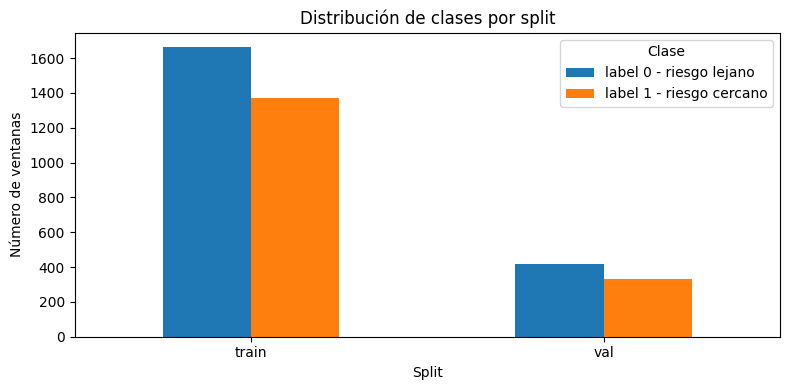

In [7]:
counts = df.groupby(["split", "label"]).size().unstack(fill_value=0).rename(columns={0:"label 0 - riesgo lejano", 1:"label 1 - riesgo cercano"})
ax = counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribución de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Número de ventanas")
ax.legend(title="Clase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Auditoría temporal: ¿todas las ventanas son pre-TOA?

Condición necesaria para poder defender anticipación:

```text
end < TOA
```

Además, los labels deben respetar los rangos generados por `make_balanced_training_txt.py`.

In [8]:
bad_post_toa = df[df["end"] >= df["toa"]]
bad_len = df[df["window_len"] != WINDOW_LEN_EXPECTED]
bad_start_end = df[df["end"] < df["start"]]
bad_labels = df[~df["label"].isin([0, 1])]

bad_pos = df[(df["label"] == 1) & ~df["gap_to_toa"].between(1, POSITIVE_HORIZON)]
bad_neg = df[(df["label"] == 0) & ~df["gap_to_toa"].between(NEGATIVE_MIN_DISTANCE, NEGATIVE_MAX_DISTANCE)]
gray_zone_rows = df[df["gap_to_toa"].between(POSITIVE_HORIZON + 1, POSITIVE_HORIZON + GRAY_ZONE)]

checks_df = pd.DataFrame([
    {"check": "end >= TOA", "bad_rows": len(bad_post_toa), "expected": 0},
    {"check": f"window_len != {WINDOW_LEN_EXPECTED}", "bad_rows": len(bad_len), "expected": 0},
    {"check": "end < start", "bad_rows": len(bad_start_end), "expected": 0},
    {"check": "label not in {0,1}", "bad_rows": len(bad_labels), "expected": 0},
    {"check": f"label 1 fuera de gap 1-{POSITIVE_HORIZON}", "bad_rows": len(bad_pos), "expected": 0},
    {"check": f"label 0 fuera de gap {NEGATIVE_MIN_DISTANCE}-{NEGATIVE_MAX_DISTANCE}", "bad_rows": len(bad_neg), "expected": 0},
    {"check": f"filas en zona gris {POSITIVE_HORIZON+1}-{POSITIVE_HORIZON+GRAY_ZONE}", "bad_rows": len(gray_zone_rows), "expected": 0},
])
checks_df["status"] = np.where(checks_df["bad_rows"] == checks_df["expected"], "OK", "REVISAR")
display(checks_df)

if len(bad_post_toa):
    display(bad_post_toa.head(10))
if len(bad_pos):
    display(bad_pos.head(10))
if len(bad_neg):
    display(bad_neg.head(10))

,check,bad_rows,expected,status
0,end >= TOA,33,0,REVISAR
1,window_len != 64,0,0,OK
2,end < start,0,0,OK
3,"label not in {0,1}",0,0,OK
4,label 1 fuera de gap 1-30,0,0,OK
5,label 0 fuera de gap 61-120,1212,0,REVISAR
6,filas en zona gris 31-60,204,0,REVISAR


,video_id,label,start,end,toa,description,raw_line,source_file,line_number,split,group_id,clip_id,window_len,gap_to_toa,start_to_toa,gap_seconds,window_seconds,is_pre_toa
262,1/045,0,129,192,0,a pedestrian crosses the road,"1/045 0 129 192 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,263,train,1,1/045_129_192,64,-192,-129,-6.400000,2.133333,False
263,1/045,0,1,64,0,a pedestrian crosses the road,"1/045 0 1 64 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,264,train,1,1/045_1_64,64,-64,-1,-2.133333,2.133333,False
522,54/002,0,321,384,0,a pedestrian crosses the road,"54/002 0 321 384 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,523,train,54,54/002_321_384,64,-384,-321,-12.800000,2.133333,False
523,54/002,0,129,192,0,a pedestrian crosses the road,"54/002 0 129 192 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,524,train,54,54/002_129_192,64,-192,-129,-6.400000,2.133333,False
824,1/016,0,1,64,0,a pedestrian crosses the road,"1/016 0 1 64 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,825,train,1,1/016_1_64,64,-64,-1,-2.133333,2.133333,False
825,1/016,0,129,192,0,a pedestrian crosses the road,"1/016 0 129 192 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,826,train,1,1/016_129_192,64,-192,-129,-6.400000,2.133333,False
1416,1/043,0,257,320,0,a pedestrian crosses the road,"1/043 0 257 320 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,1417,train,1,1/043_257_320,64,-320,-257,-10.666667,2.133333,False
1417,1/043,0,65,128,0,a pedestrian crosses the road,"1/043 0 65 128 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,1418,train,1,1/043_65_128,64,-128,-65,-4.266667,2.133333,False
1570,8/028,0,257,320,0,lead vehicle stops,"8/028 0 257 320 0,lead vehicle stops",/data-fast/data-server/vlopezmo/model/training...,1571,train,8,8/028_257_320,64,-320,-257,-10.666667,2.133333,False
1571,8/028,0,321,384,0,lead vehicle stops,"8/028 0 321 384 0,lead vehicle stops",/data-fast/data-server/vlopezmo/model/training...,1572,train,8,8/028_321_384,64,-384,-321,-12.800000,2.133333,False


,video_id,label,start,end,toa,description,raw_line,source_file,line_number,split,group_id,clip_id,window_len,gap_to_toa,start_to_toa,gap_seconds,window_seconds,is_pre_toa
2,10/005,0,161,224,356,ego-car goes straight crossing paths at non-si...,"10/005 0 161 224 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,3,train,10,10/005_161_224,64,132,195,4.400000,2.133333,True
3,10/005,0,129,192,356,ego-car goes straight crossing paths at non-si...,"10/005 0 129 192 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,4,train,10,10/005_129_192,64,164,227,5.466667,2.133333,True
8,43/208,0,1,64,186,a vehicle crosses the road,"43/208 0 1 64 186,a vehicle crosses the road",/data-fast/data-server/vlopezmo/model/training...,9,train,43,43/208_1_64,64,122,185,4.066667,2.133333,True
11,5/114,0,17,80,253,a motorbike crosses the road,"5/114 0 17 80 253,a motorbike crosses the road",/data-fast/data-server/vlopezmo/model/training...,12,train,5,5/114_17_80,64,173,236,5.766667,2.133333,True
15,50/117,0,1,64,225,a motorbike crosses the road,"50/117 0 1 64 225,a motorbike crosses the road",/data-fast/data-server/vlopezmo/model/training...,16,train,50,50/117_1_64,64,161,224,5.366667,2.133333,True
18,13/005,0,65,128,280,there is an object crash,"13/005 0 65 128 280,there is an object crash",/data-fast/data-server/vlopezmo/model/training...,19,train,13,13/005_65_128,64,152,215,5.066667,2.133333,True
20,12/014,0,129,192,343,a vehicle changes lanes with the same directio...,"12/014 0 129 192 343,a vehicle changes lanes w...",/data-fast/data-server/vlopezmo/model/training...,21,train,12,12/014_129_192,64,151,214,5.033333,2.133333,True
25,50/118,0,1,64,100,a vehicle turns left across path at non-signal...,"50/118 0 1 64 100,a vehicle turns left across ...",/data-fast/data-server/vlopezmo/model/training...,26,train,50,50/118_1_64,64,36,99,1.200000,2.133333,True
31,10/034,0,177,240,412,ego-car accelerately goes straight at non-sign...,"10/034 0 177 240 412,ego-car accelerately goes...",/data-fast/data-server/vlopezmo/model/training...,32,train,10,10/034_177_240,64,172,235,5.733333,2.133333,True
36,43/163,0,1,64,190,lead vehicle stops,"43/163 0 1 64 190,lead vehicle stops",/data-fast/data-server/vlopezmo/model/training...,37,train,43,43/163_1_64,64,126,189,4.200000,2.133333,True


## 4. Distribución de `gap_to_toa`

La gráfica más importante del EDA:

```text
gap_to_toa = TOA - end
```

Debe separar label 1 como riesgo cercano y label 0 como riesgo lejano.

In [9]:
stats_gap = df.groupby(["split", "label"])["gap_to_toa"].agg(
    count="count",
    min="min",
    q25=lambda x: x.quantile(0.25),
    median="median",
    mean="mean",
    q75=lambda x: x.quantile(0.75),
    max="max",
).reset_index()
display(stats_gap)

,split,label,count,min,q25,median,mean,q75,max
0,train,0,1662,-384,96.25,118.0,112.327918,141.75,180
1,train,1,1373,1,6.00,10.0,10.568099,16.00,20
2,val,0,420,-384,101.75,120.0,110.833333,141.25,180
3,val,1,334,1,6.00,11.0,10.769461,16.00,20


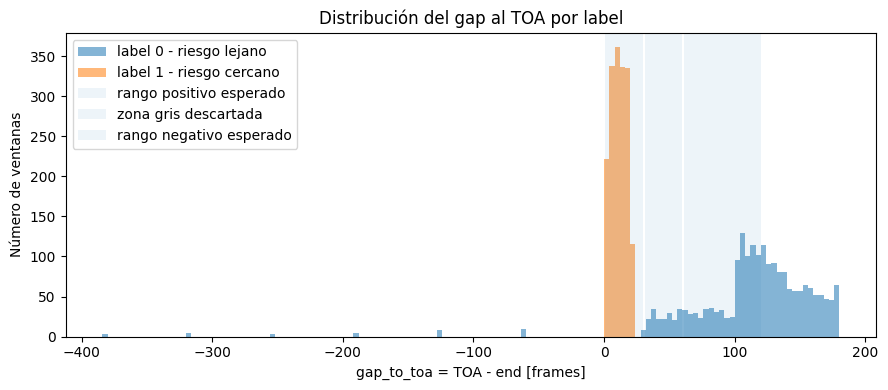

In [10]:
plt.figure(figsize=(9, 4))
for label, label_name in [(0, "label 0 - riesgo lejano"), (1, "label 1 - riesgo cercano")]:
    subset = df[df["label"] == label]["gap_to_toa"]
    plt.hist(subset, bins=range(int(df["gap_to_toa"].min()), int(df["gap_to_toa"].max()) + 2, 4), alpha=0.55, label=label_name)
plt.axvspan(1, POSITIVE_HORIZON, alpha=0.08, label="rango positivo esperado")
plt.axvspan(POSITIVE_HORIZON + 1, POSITIVE_HORIZON + GRAY_ZONE, alpha=0.08, label="zona gris descartada")
plt.axvspan(NEGATIVE_MIN_DISTANCE, NEGATIVE_MAX_DISTANCE, alpha=0.08, label="rango negativo esperado")
plt.title("Distribución del gap al TOA por label")
plt.xlabel("gap_to_toa = TOA - end [frames]")
plt.ylabel("Número de ventanas")
plt.legend()
plt.tight_layout()
plt.show()

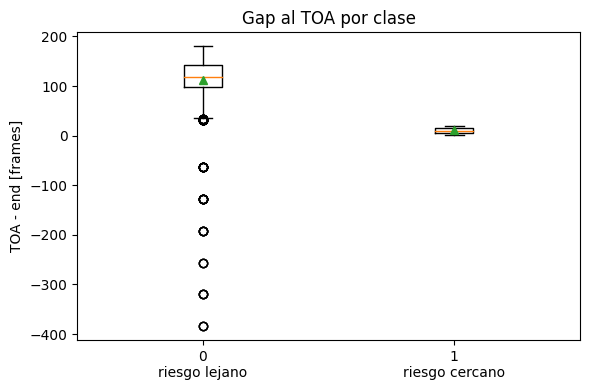

In [11]:
labels = ["0\nriesgo lejano", "1\nriesgo cercano"]
data = [df[df["label"] == 0]["gap_to_toa"], df[df["label"] == 1]["gap_to_toa"]]
plt.figure(figsize=(6, 4))
plt.boxplot(data, labels=labels, showmeans=True)
plt.title("Gap al TOA por clase")
plt.ylabel("TOA - end [frames]")
plt.tight_layout()
plt.show()

## 5. Validación del split: fuga train/validation

Debe ser 0:

```text
vídeos compartidos entre train y validation = 0
```

In [12]:
train_videos = set(train_df["video_id"])
val_videos = set(val_df["video_id"])
overlap_videos = sorted(train_videos & val_videos)

split_check = pd.DataFrame([
    {"metric": "vídeos únicos train", "value": len(train_videos)},
    {"metric": "vídeos únicos val", "value": len(val_videos)},
    {"metric": "vídeos compartidos train-val", "value": len(overlap_videos)},
])
display(split_check)

if overlap_videos:
    print("Vídeos compartidos. REVISAR:")
    print(overlap_videos[:50])
else:
    print("OK: no hay solapamiento de video_id entre train y validation.")

,metric,value
0,vídeos únicos train,1110
1,vídeos únicos val,277
2,vídeos compartidos train-val,0


OK: no hay solapamiento de video_id entre train y validation.


## 6. Ventanas por vídeo

Analiza si cada vídeo tiene ambas clases, solo positivos o solo negativos.

In [13]:
per_video = df.groupby(["split", "video_id"]).agg(
    n_windows=("clip_id", "count"),
    n_pos=("label", lambda x: int((x == 1).sum())),
    n_neg=("label", lambda x: int((x == 0).sum())),
    toa=("toa", "first"),
    description=("description", "first"),
    min_gap=("gap_to_toa", "min"),
    max_gap=("gap_to_toa", "max"),
).reset_index()
per_video["class_pattern"] = np.select(
    [
        (per_video["n_pos"] > 0) & (per_video["n_neg"] > 0),
        (per_video["n_pos"] > 0) & (per_video["n_neg"] == 0),
        (per_video["n_pos"] == 0) & (per_video["n_neg"] > 0),
    ],
    ["ambas clases", "solo positivos", "solo negativos"],
    default="sin clases",
)

display(per_video.head())
display(per_video.groupby(["split", "class_pattern"]).size().unstack(fill_value=0))
display(per_video["n_windows"].describe().to_frame("n_windows"))

,split,video_id,n_windows,n_pos,n_neg,toa,description,min_gap,max_gap,class_pattern
0,train,1/002,2,1,1,168,a pedestrian crosses the road,8,104,ambas clases
1,train,1/004,3,1,2,360,a pedestrian crosses the road,8,152,ambas clases
2,train,1/006,3,1,2,280,a pedestrian crosses the road,8,168,ambas clases
3,train,1/008,1,1,0,90,a pedestrian crosses the road,10,10,solo positivos
4,train,1/009,1,1,0,93,a pedestrian crosses the road,13,13,solo positivos


class_pattern,ambas clases,solo negativos,solo positivos
split,,,
train,1064,11,35
val,262,6,9


,n_windows
count,1387.000000
mean,2.731795
std,0.700560
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000


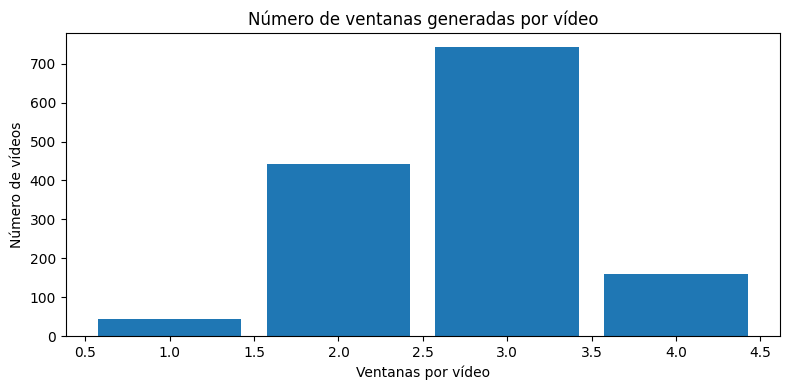

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(per_video["n_windows"], bins=range(1, int(per_video["n_windows"].max()) + 2), align="left", rwidth=0.85)
plt.title("Número de ventanas generadas por vídeo")
plt.xlabel("Ventanas por vídeo")
plt.ylabel("Número de vídeos")
plt.tight_layout()
plt.show()

## 7. Distribución de escenarios / descripciones

Audita si train y validation tienen tipos de accidente similares y si alguna categoría domina.

In [15]:
scenario_counts = df["description"].value_counts().reset_index()
scenario_counts.columns = ["description", "samples"]
display(scenario_counts.head(25))

,description,samples
0,a motorbike crosses the road,480
1,a vehicle changes lanes with the same directio...,336
2,lead vehicle stops,257
3,a vehicle crosses the road,244
4,a motorbike is out of control,202
5,a vehicle is out of control,201
6,a pedestrian crosses the road,148
7,a vehicle overtakes,125
8,a vehicle changes lanes with the same directio...,125
9,lead vehicle stops,99


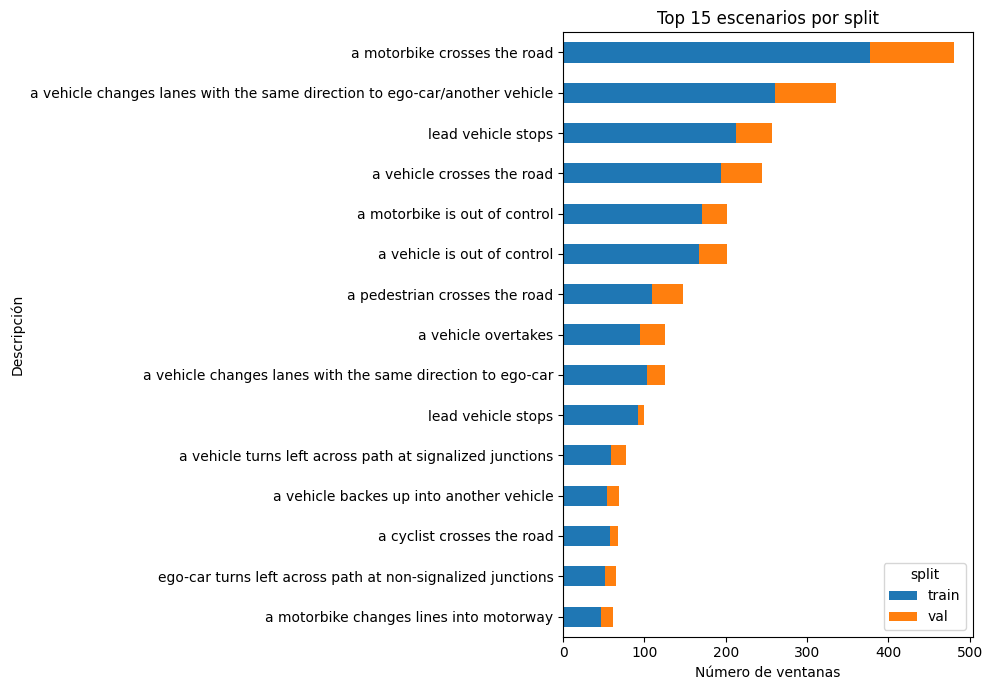

In [16]:
TOP_N = 15
top_scenarios = df["description"].value_counts().head(TOP_N).index
plot_df = df[df["description"].isin(top_scenarios)]
ct = pd.crosstab(plot_df["description"], plot_df["split"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

ax = ct.plot(kind="barh", stacked=True, figsize=(10, 7))
ax.set_title(f"Top {TOP_N} escenarios por split")
ax.set_xlabel("Número de ventanas")
ax.set_ylabel("Descripción")
plt.tight_layout()
plt.show()

In [17]:
train_scen = set(train_df["description"])
val_scen = set(val_df["description"])
only_train = sorted(train_scen - val_scen)
only_val = sorted(val_scen - train_scen)

scenario_split_summary = pd.DataFrame([
    {"metric": "escenarios únicos train", "value": len(train_scen)},
    {"metric": "escenarios únicos val", "value": len(val_scen)},
    {"metric": "escenarios compartidos", "value": len(train_scen & val_scen)},
    {"metric": "escenarios solo train", "value": len(only_train)},
    {"metric": "escenarios solo val", "value": len(only_val)},
])
display(scenario_split_summary)

print("Ejemplos escenarios solo validation:")
for s in only_val[:20]:
    print("-", s)

,metric,value
0,escenarios únicos train,86
1,escenarios únicos val,63
2,escenarios compartidos,56
3,escenarios solo train,30
4,escenarios solo val,7


Ejemplos escenarios solo validation:
- a cyclist turns right across path at signalized junctions
- a vehicle changes lanes - same direction
- a vehicle makes a dodge action
- a vehicle turns on a road with the opposite direction to
- ego-car goes straight at non-signalized junctions
- ego-car turns right across path at signalized junctions
- lead cyclist stops


In [18]:
scenario_label = pd.crosstab(df["description"], df["label"])
scenario_label.columns = ["label_0_far", "label_1_near"]
scenario_label["total"] = scenario_label.sum(axis=1)
scenario_label["positive_rate"] = scenario_label["label_1_near"] / scenario_label["total"]
display(scenario_label.sort_values("total", ascending=False).head(25))

,label_0_far,label_1_near,total,positive_rate
description,,,,
a motorbike crosses the road,254,226,480,0.470833
a vehicle changes lanes with the same direction to ego-car/another vehicle,188,148,336,0.440476
lead vehicle stops,141,116,257,0.451362
a vehicle crosses the road,135,109,244,0.446721
a motorbike is out of control,108,94,202,0.465347
a vehicle is out of control,113,88,201,0.437811
a pedestrian crosses the road,78,70,148,0.472973
a vehicle overtakes,70,55,125,0.440000
a vehicle changes lanes with the same direction to ego-car,75,50,125,0.400000


## 8. Distribución por `group_id`

Los IDs tienen forma `grupo/vídeo`, por ejemplo `49/022`. Este análisis ayuda a detectar sesgos por grupo/carpeta.

In [19]:
group_summary = df.groupby("group_id").agg(
    samples=("clip_id", "count"),
    videos=("video_id", "nunique"),
    positive_rate=("label", "mean"),
    mean_gap=("gap_to_toa", "mean"),
).sort_values("samples", ascending=False)
display(group_summary.head(30))

ct_group_split = pd.crosstab(df["group_id"], df["split"])
ct_group_split["total"] = ct_group_split.sum(axis=1)
display(ct_group_split.sort_values("total", ascending=False).head(30))

,samples,videos,positive_rate,mean_gap
group_id,,,,
11,516,182,0.434109,68.565891
5,369,131,0.463415,69.289973
10,353,123,0.427762,72.906516
43,326,127,0.457055,64.346626
6,280,100,0.460714,68.728571
50,255,98,0.478431,63.380392
48,162,59,0.462963,68.049383
37,133,53,0.473684,57.248120
8,131,48,0.419847,54.282443


split,train,val,total
group_id,,,
11,448,68,516
5,289,80,369
10,272,81,353
43,278,48,326
6,243,37,280
50,201,54,255
48,109,53,162
37,108,25,133
8,114,17,131


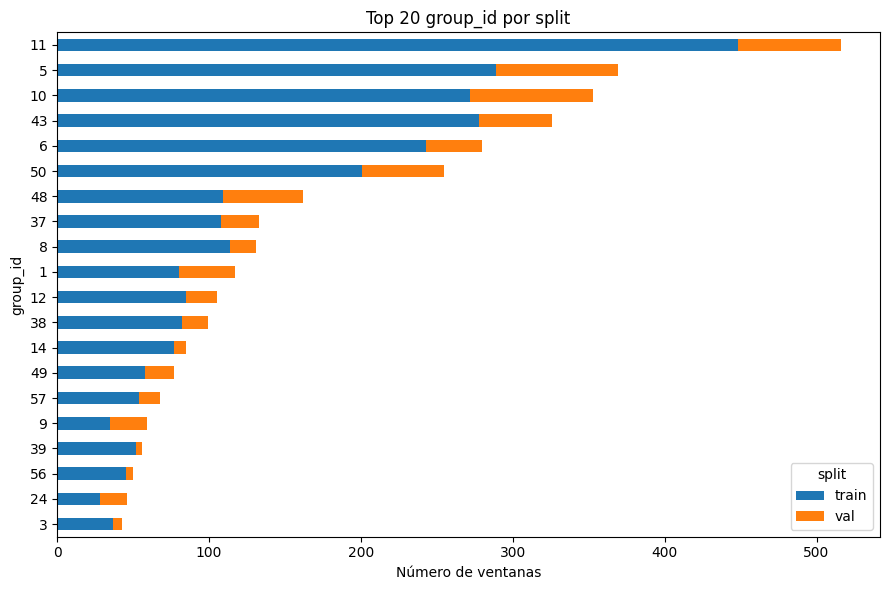

In [20]:
TOP_GROUPS = 20
top_groups = df["group_id"].value_counts().head(TOP_GROUPS).index
ct = pd.crosstab(df[df["group_id"].isin(top_groups)]["group_id"], df[df["group_id"].isin(top_groups)]["split"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]
ax = ct.plot(kind="barh", stacked=True, figsize=(9, 6))
ax.set_title(f"Top {TOP_GROUPS} group_id por split")
ax.set_xlabel("Número de ventanas")
ax.set_ylabel("group_id")
plt.tight_layout()
plt.show()

## 9. Solapamiento temporal entre ventanas

Con `window_len=64` y `stride=16`, el solapamiento esperado entre ventanas consecutivas es aproximadamente 75%.

Esto refuerza que el split por vídeo sea obligatorio.

In [21]:
df_sorted = df.sort_values(["video_id", "start", "end"]).copy()
df_sorted["start_diff"] = df_sorted.groupby("video_id")["start"].diff()
df_sorted["prev_end"] = df_sorted.groupby("video_id")["end"].shift(1)
df_sorted["overlap_frames_with_prev"] = (df_sorted["prev_end"] - df_sorted["start"] + 1).clip(lower=0)
df_sorted["overlap_ratio_with_prev"] = df_sorted["overlap_frames_with_prev"] / df_sorted["window_len"]

display(df_sorted["start_diff"].dropna().describe().to_frame("start_diff"))
display(df_sorted["overlap_ratio_with_prev"].dropna().describe().to_frame("overlap_ratio"))
print("Start diffs más frecuentes:")
display(df_sorted["start_diff"].value_counts().head(10).to_frame("count"))

,start_diff
count,2402.000000
mean,59.357202
std,40.959420
min,16.000000
25%,16.000000
50%,48.000000
75%,96.000000
max,320.000000


,overlap_ratio
count,2402.000000
mean,0.325354
std,0.334788
min,0.000000
25%,0.000000
50%,0.250000
75%,0.750000
max,0.750000


Start diffs más frecuentes:


,count
16.0,780
96.0,471
32.0,284
48.0,218
112.0,196
64.0,168
128.0,115
80.0,110
144.0,53
192.0,6


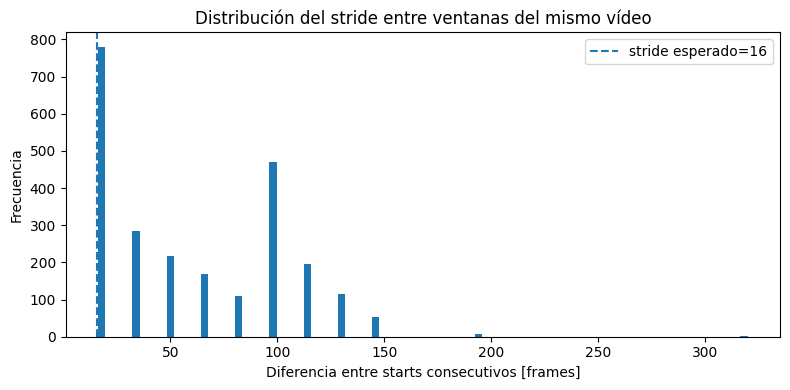

In [22]:
plt.figure(figsize=(8, 4))
vals = df_sorted["start_diff"].dropna()
if len(vals):
    plt.hist(vals, bins=range(int(vals.min()), int(vals.max()) + 2, 4), rwidth=0.85)
plt.axvline(STRIDE_EXPECTED, linestyle="--", label=f"stride esperado={STRIDE_EXPECTED}")
plt.title("Distribución del stride entre ventanas del mismo vídeo")
plt.xlabel("Diferencia entre starts consecutivos [frames]")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Qué ve realmente el modelo X3D-S + GRU

Ventana original: 64 frames.

Entrada al modelo: 16 frames muestreados uniformemente.

X3D-S internamente: 4 subclips de 13 frames si `subclip_len=13` y `stride=1`.

In [23]:
def selected_frames_for_model(start, end, num_frames=NUM_FRAMES_MODEL):
    return np.round(np.linspace(start, end, num_frames)).astype(int)

sampled = []
for _, row in df.iterrows():
    selected = selected_frames_for_model(row["start"], row["end"])
    diffs = np.diff(selected)
    n_subclips = max(0, 1 + (len(selected) - X3D_SUBCLIP_LEN) // X3D_SUBCLIP_STRIDE)
    sampled.append({
        "clip_id": row["clip_id"],
        "selected_first": int(selected[0]),
        "selected_last": int(selected[-1]),
        "selected_min_diff": int(diffs.min()) if len(diffs) else np.nan,
        "selected_max_diff": int(diffs.max()) if len(diffs) else np.nan,
        "selected_mean_diff": float(diffs.mean()) if len(diffs) else np.nan,
        "n_selected_frames": len(selected),
        "n_x3d_subclips": n_subclips,
        "last_selected_before_toa": bool(selected[-1] < row["toa"]),
    })

sampled_df = pd.DataFrame(sampled)
df_model = df.merge(sampled_df, on="clip_id", how="left")

display(df_model[["n_selected_frames", "selected_mean_diff", "selected_min_diff", "selected_max_diff", "n_x3d_subclips", "last_selected_before_toa"]].describe(include="all"))

bad_model_toa = df_model[~df_model["last_selected_before_toa"]]
print("Filas donde el último frame seleccionado no es pre-TOA:", len(bad_model_toa))
if len(bad_model_toa):
    display(bad_model_toa.head(10))

,n_selected_frames,selected_mean_diff,selected_min_diff,selected_max_diff,n_x3d_subclips,last_selected_before_toa
count,3789.0,3.789000e+03,3789.0,3789.0,3789.0,3789
unique,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,3756
mean,16.0,4.200000e+00,4.0,5.0,4.0,NaN
std,0.0,8.882956e-16,0.0,0.0,0.0,NaN
min,16.0,4.200000e+00,4.0,5.0,4.0,NaN
25%,16.0,4.200000e+00,4.0,5.0,4.0,NaN
50%,16.0,4.200000e+00,4.0,5.0,4.0,NaN
75%,16.0,4.200000e+00,4.0,5.0,4.0,NaN


Filas donde el último frame seleccionado no es pre-TOA: 33


,video_id,label,start,end,toa,description,raw_line,source_file,line_number,split,group_id,clip_id,window_len,gap_to_toa,start_to_toa,gap_seconds,window_seconds,is_pre_toa,selected_first,selected_last,selected_min_diff,selected_max_diff,selected_mean_diff,n_selected_frames,n_x3d_subclips,last_selected_before_toa
262,1/045,0,129,192,0,a pedestrian crosses the road,"1/045 0 129 192 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,263,train,1,1/045_129_192,64,-192,-129,-6.400000,2.133333,False,129,192,4,5,4.2,16,4,False
263,1/045,0,1,64,0,a pedestrian crosses the road,"1/045 0 1 64 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,264,train,1,1/045_1_64,64,-64,-1,-2.133333,2.133333,False,1,64,4,5,4.2,16,4,False
522,54/002,0,321,384,0,a pedestrian crosses the road,"54/002 0 321 384 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,523,train,54,54/002_321_384,64,-384,-321,-12.800000,2.133333,False,321,384,4,5,4.2,16,4,False
523,54/002,0,129,192,0,a pedestrian crosses the road,"54/002 0 129 192 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,524,train,54,54/002_129_192,64,-192,-129,-6.400000,2.133333,False,129,192,4,5,4.2,16,4,False
824,1/016,0,1,64,0,a pedestrian crosses the road,"1/016 0 1 64 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,825,train,1,1/016_1_64,64,-64,-1,-2.133333,2.133333,False,1,64,4,5,4.2,16,4,False
825,1/016,0,129,192,0,a pedestrian crosses the road,"1/016 0 129 192 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,826,train,1,1/016_129_192,64,-192,-129,-6.400000,2.133333,False,129,192,4,5,4.2,16,4,False
1416,1/043,0,257,320,0,a pedestrian crosses the road,"1/043 0 257 320 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,1417,train,1,1/043_257_320,64,-320,-257,-10.666667,2.133333,False,257,320,4,5,4.2,16,4,False
1417,1/043,0,65,128,0,a pedestrian crosses the road,"1/043 0 65 128 0,a pedestrian crosses the road",/data-fast/data-server/vlopezmo/model/training...,1418,train,1,1/043_65_128,64,-128,-65,-4.266667,2.133333,False,65,128,4,5,4.2,16,4,False
1570,8/028,0,257,320,0,lead vehicle stops,"8/028 0 257 320 0,lead vehicle stops",/data-fast/data-server/vlopezmo/model/training...,1571,train,8,8/028_257_320,64,-320,-257,-10.666667,2.133333,False,257,320,4,5,4.2,16,4,False
1571,8/028,0,321,384,0,lead vehicle stops,"8/028 0 321 384 0,lead vehicle stops",/data-fast/data-server/vlopezmo/model/training...,1572,train,8,8/028_321_384,64,-384,-321,-12.800000,2.133333,False,321,384,4,5,4.2,16,4,False


In [24]:
example_cols = ["video_id", "label", "start", "end", "toa", "gap_to_toa", "description"]
examples = df.sample(min(5, len(df)), random_state=42)[example_cols].copy()
examples["selected_frames"] = examples.apply(lambda r: selected_frames_for_model(r["start"], r["end"]).tolist(), axis=1)
display(examples)

,video_id,label,start,end,toa,gap_to_toa,description,selected_frames
1580,56/012,0,33,96,217,121,a vehicle turns left across path at signalized...,"[33, 37, 41, 46, 50, 54, 58, 62, 67, 71, 75, 7..."
2257,3/011,0,1,64,170,106,a cyclist crosses the road,"[1, 5, 9, 14, 18, 22, 26, 30, 35, 39, 43, 47, ..."
263,1/045,0,1,64,0,-64,a pedestrian crosses the road,"[1, 5, 9, 14, 18, 22, 26, 30, 35, 39, 43, 47, ..."
1837,48/042,0,1,64,150,86,a vehicle changes lanes with the same directio...,"[1, 5, 9, 14, 18, 22, 26, 30, 35, 39, 43, 47, ..."
3653,12/024,0,49,112,218,106,a vehicle overtakes,"[49, 53, 57, 62, 66, 70, 74, 78, 83, 87, 91, 9..."


## 11. Bins de gap para evaluación posterior del modelo

Esto no entrena el modelo, pero prepara un análisis muy útil:

> ¿La probabilidad media de riesgo sube al acercarse al TOA?

In [25]:
gap_bins = [-np.inf, 0, 30, 60, 90, 120, np.inf]
gap_labels = ["post/invalid", "1-30", "31-60 gray", "61-90", "91-120", ">120"]
df["gap_bin"] = pd.cut(df["gap_to_toa"], bins=gap_bins, labels=gap_labels, right=True)

gap_bin_table = pd.crosstab(df["gap_bin"], df["label"], dropna=False)
gap_bin_table.columns = ["label_0_far", "label_1_near"]
gap_bin_table["total"] = gap_bin_table.sum(axis=1)
display(gap_bin_table)

,label_0_far,label_1_near,total
gap_bin,,,
post/invalid,33,0,33
1-30,0,1707,1707
31-60 gray,204,0,204
61-90,227,0,227
91-120,643,0,643
>120,975,0,975


## 12. Opcional: auditar `training_balanced.txt` si existe

In [26]:
if BALANCED_TXT.exists():
    balanced_df = load_txt(BALANCED_TXT, "balanced_total")
    display(split_summary(balanced_df))
    balanced_checks = pd.DataFrame([
        {"check": "end >= TOA", "bad_rows": len(balanced_df[balanced_df["end"] >= balanced_df["toa"]])},
        {"check": f"label 1 fuera de gap 1-{POSITIVE_HORIZON}", "bad_rows": len(balanced_df[(balanced_df["label"] == 1) & ~balanced_df["gap_to_toa"].between(1, POSITIVE_HORIZON)])},
        {"check": f"label 0 fuera de gap {NEGATIVE_MIN_DISTANCE}-{NEGATIVE_MAX_DISTANCE}", "bad_rows": len(balanced_df[(balanced_df["label"] == 0) & ~balanced_df["gap_to_toa"].between(NEGATIVE_MIN_DISTANCE, NEGATIVE_MAX_DISTANCE)])},
    ])
    balanced_checks["status"] = np.where(balanced_checks["bad_rows"] == 0, "OK", "REVISAR")
    display(balanced_checks)
else:
    print("No existe BALANCED_TXT. Omitido.")

,split,samples,unique_videos,unique_groups,label_0_far,label_1_near,positive_rate,mean_gap,median_gap
0,balanced_total,3789,1387,51,2082,1707,0.450515,66.335709,54.0
1,total,3789,1387,51,2082,1707,0.450515,66.335709,54.0


,check,bad_rows,status
0,end >= TOA,33,REVISAR
1,label 1 fuera de gap 1-30,0,OK
2,label 0 fuera de gap 61-120,1212,REVISAR


## 13. Opcional: EDA visual de frames

Activa `RGB_ROOT` para mostrar imágenes. Recomendación para la memoria: mostrar para un mismo vídeo una ventana `label=0` y una ventana `label=1` con primer frame, frame central y último frame.

In [27]:
try:
    from PIL import Image
except Exception:
    Image = None


def find_frame_path(rgb_root: Path, video_id: str, frame_idx: int):
    if rgb_root is None:
        return None
    video_dir = Path(rgb_root) / video_id
    candidates = []
    for ext in ["png", "jpg", "jpeg"]:
        candidates.extend([
            video_dir / f"{frame_idx:04d}.{ext}",
            video_dir / f"{frame_idx:05d}.{ext}",
            video_dir / f"{frame_idx:06d}.{ext}",
            video_dir / f"{frame_idx}.{ext}",
        ])
    for p in candidates:
        if p.exists():
            return p
    return None


def plot_window_triplet(row, rgb_root):
    if Image is None:
        print("PIL no está disponible.")
        return
    frames = [row["start"], int(round((row["start"] + row["end"]) / 2)), row["end"]]
    titles = ["start", "middle", "end"]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    for ax, fr, title in zip(axes, frames, titles):
        p = find_frame_path(rgb_root, row["video_id"], fr)
        ax.axis("off")
        ax.set_title(f"{title}\nframe {fr}")
        if p is None:
            ax.text(0.5, 0.5, "frame no encontrado", ha="center", va="center")
        else:
            img = Image.open(p).convert("RGB")
            ax.imshow(img)
    fig.suptitle(f"{row['video_id']} | label={row['label']} | gap={row['gap_to_toa']} | {row['description']}")
    plt.tight_layout()
    plt.show()

if RGB_ROOT is None:
    print("RGB_ROOT no configurado. Define RGB_ROOT para activar visualización de frames.")
else:
    RGB_ROOT = Path(RGB_ROOT)
    both = per_video[per_video["class_pattern"] == "ambas clases"]
    if both.empty:
        print("No hay vídeos con ambas clases en el dataframe actual.")
    else:
        vid = both.iloc[0]["video_id"]
        rows = df[df["video_id"] == vid].sort_values(["label", "gap_to_toa"])
        display(rows[["video_id", "label", "start", "end", "toa", "gap_to_toa", "description"]])
        for _, row in rows.iterrows():
            plot_window_triplet(row, RGB_ROOT)

RGB_ROOT no configurado. Define RGB_ROOT para activar visualización de frames.


## 14. Exportar tablas para la memoria

In [30]:
OUTPUT_DIR = Path("/data-fast/data-server/vlopezmo/model/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(OUTPUT_DIR / "summary_splits.csv", index=False)
checks_df.to_csv(OUTPUT_DIR / "temporal_integrity_checks.csv", index=False)
stats_gap.to_csv(OUTPUT_DIR / "gap_stats_by_split_label.csv", index=False)
per_video.to_csv(OUTPUT_DIR / "per_video_summary.csv", index=False)
scenario_counts.to_csv(OUTPUT_DIR / "scenario_counts.csv", index=False)
scenario_label.to_csv(OUTPUT_DIR / "scenario_label_distribution.csv")
group_summary.to_csv(OUTPUT_DIR / "group_summary.csv")

print("Tablas exportadas en:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)

Tablas exportadas en: /data-fast/data-server/vlopezmo/model/eda_outputs
- gap_stats_by_split_label.csv
- group_summary.csv
- per_video_summary.csv
- scenario_counts.csv
- scenario_label_distribution.csv
- summary_splits.csv
- temporal_integrity_checks.csv


## 15. Conclusiones automáticas para revisar

Úsalas como borrador para la memoria.

In [31]:
all_temporal_ok = (
    len(bad_post_toa) == 0 and
    len(bad_pos) == 0 and
    len(bad_neg) == 0 and
    len(gray_zone_rows) == 0
)
leakage_ok = len(overlap_videos) == 0
window_len_ok = len(bad_len) == 0

print("Conclusiones del EDA:\n")

if all_temporal_ok:
    print("✅ Todas las ventanas respetan la formulación pre-TOA y los rangos temporales definidos para label 0/1.")
else:
    print("⚠️ Hay inconsistencias temporales. Revisa temporal_integrity_checks.csv.")

if leakage_ok:
    print("✅ No hay solapamiento de video_id entre train y validation. El split evita fuga directa por vídeo.")
else:
    print("⚠️ Hay vídeos compartidos entre train y validation. Esto invalida la evaluación si no se corrige.")

if window_len_ok:
    print(f"✅ Todas las ventanas tienen longitud esperada de {WINDOW_LEN_EXPECTED} frames.")
else:
    print("⚠️ Hay ventanas con longitud distinta a la esperada.")

print(f"\nMuestras totales: {len(df)}")
print(f"Vídeos únicos: {df['video_id'].nunique()}")
print(f"Tasa positiva global: {(df['label'] == 1).mean():.3f}")
print(f"Gap medio label 1: {df[df['label'] == 1]['gap_to_toa'].mean():.2f} frames")
print(f"Gap medio label 0: {df[df['label'] == 0]['gap_to_toa'].mean():.2f} frames")

print("\nFrase sugerida para la memoria:")
print("El dataset final se formula como una tarea de anticipación de riesgo a nivel de ventana temporal. Todas las muestras finalizan antes del Time of Accident; las positivas corresponden a ventanas cercanas al evento crítico, mientras que las negativas representan ventanas temporalmente más alejadas. El split se realiza a nivel de vídeo para evitar fuga de información entre entrenamiento y validación.")

Conclusiones del EDA:

⚠️ Hay inconsistencias temporales. Revisa temporal_integrity_checks.csv.
✅ No hay solapamiento de video_id entre train y validation. El split evita fuga directa por vídeo.
✅ Todas las ventanas tienen longitud esperada de 64 frames.

Muestras totales: 3789
Vídeos únicos: 1387
Tasa positiva global: 0.451
Gap medio label 1: 10.61 frames
Gap medio label 0: 112.03 frames

Frase sugerida para la memoria:
El dataset final se formula como una tarea de anticipación de riesgo a nivel de ventana temporal. Todas las muestras finalizan antes del Time of Accident; las positivas corresponden a ventanas cercanas al evento crítico, mientras que las negativas representan ventanas temporalmente más alejadas. El split se realiza a nivel de vídeo para evitar fuga de información entre entrenamiento y validación.
